# 02 · Adapformer paso a paso

**Paper:** *Adapformer: Adaptive channel management for multivariate time series forecasting* — Luo, Li, Peng, Gong,
*Neural Networks* 193 (2026) 107988.

En este notebook construimos el modelo **pieza por pieza**, pasando un batch real por cada componente e imprimiendo
las formas. La implementación está en [`src/modelos.py`](../src/modelos.py) (propia, PyTorch puro, sin usar código del
paper).

## 0. La idea en una frase

> Los modelos *channel-independent* (CI: cada variable se predice sólo con su historia) son robustos pero ignoran
> relaciones entre variables; los *channel-dependent* (CD: mezclan todo) capturan relaciones pero se contaminan con
> variables irrelevantes. **Adapformer gestiona los canales de forma adaptativa:** enriquece cada canal (ACE), deja
> que se comuniquen con atención (encoder) y, al predecir, usa sólo los **k canales más parecidos** al objetivo, elegidos
> **por muestra** con una matriz de similitud aprendida (SimBlock + ACF).

```
X [B,336,12] ─RevIN─► X_norm ─────────────────────────SimBlock──► W_dec [B,12,12]
                        │                                             │ (top-k de la fila del caudal)
                        └─► transponer [B,12,336] ─Linear(336→D)─► tokens [B,12,D] ─ACE─► ─Encoder─► ─ACF─► ŷ [B,48]
```

| Componente | Ecuación del paper | Qué hace |
|---|---|---|
| RevIN | Ec. 1 | Normaliza cada ventana con su propia media/σ; se revierte en la salida |
| Embedding invertido | Alg. 1 l.5 | Cada **canal completo** (336 h) es un token (estilo iTransformer) |
| ACE | Alg. 1 l.6–12 | Realce de bajo rango: reinyecta "modos dominantes" en cada token |
| Encoder | Alg. 1 l.17–19 | Atención **entre canales** (12 tokens), no entre instantes |
| SimBlock | Ec. 4–5 | Matriz de similitud entre canales `W_dec` |
| ACF | Ec. 2–3 | Predictor que sólo mira el objetivo + sus k−1 canales más similares |
| Pérdida | Ec. 6 | MSE + ‖W_y − W_dec‖² (W_y = similitud del **futuro** real) |

In [1]:
import sys, json, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()   # Entrega_Lab2/

sys.path.insert(0, str(ROOT / "src"))
from datos import DATASET          # dataset/ junto a Entrega_Lab2/ (o la variable de entorno LAB2_DATA_DIR)
sys.path.insert(0, str(DATASET))
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
print("Proyecto:", ROOT)
import torch, inspect
from modelos import RevIN, SimBlock, ACE, ACF, Adapformer, LSTMBase, TARGET
from datos import cargar, mapa_cuencas
torch.manual_seed(0)
dev = "cuda" if torch.cuda.is_available() else "cpu"
va = cargar("validation", dev)
xb = va["X"][:8].float()          # batch real de 8 ventanas, ya con log1p + z-score
print("x:", tuple(xb.shape), "→ (batch, tiempo, canal)")

Proyecto: D:\MAESTRIA DATA SCIENCE\semestre5\deep_learning\tarea02\Lab2_Estudio2
x: (8, 336, 12) → (batch, tiempo, canal)


## 1. RevIN — normalización reversible (Ec. 1)

Problema: cada cuenca y cada época del año tienen niveles distintos de caudal. Si el modelo ve niveles absolutos tiene
que aprender cada nivel. RevIN normaliza **cada ventana con su propia media y σ** (por canal) para que el modelo vea
*formas*; al final se usa esa misma media/σ para volver a la escala real. Tiene un peso y sesgo aprendibles por canal.

**Adaptación (anclaje):** en lugar de `ŷ = media + σ·ŷ_norm` usamos `ŷ = último_valor + σ·ŷ_norm`: el modelo predice
el **cambio** respecto al último caudal observado.

In [2]:
print(inspect.getsource(RevIN))
rev = RevIN(12).to(dev)
xn = rev.norm(xb)
print("media por canal tras RevIN (≈0):", xn.mean(1)[0].detach().cpu().numpy().round(3))
print("σ por canal tras RevIN (≈1):   ", xn.std(1)[0].detach().cpu().numpy().round(3))
y0 = torch.zeros(8, 48, device=dev)
print("si el modelo predice 0 cambios, con anclaje la salida = último caudal:",
      torch.allclose(rev.denorm_target(y0, anchor_last=True)[:, 0], xb[:, -1, TARGET], atol=1e-4))

class RevIN(nn.Module):
    """Normalización de instancia reversible (Kim et al., 2021) — Ec. 1 del paper.

    Cada ventana se normaliza con SU media y desviación (por canal) → el modelo ve formas, no niveles.
    Al final se revierte sólo para el canal objetivo. `anchor_last=True` (adaptación del compañero):
    la salida se interpreta como desviación respecto al ÚLTIMO caudal observado, no respecto a la media.
    """

    def __init__(self, n: int, eps: float = 1e-5):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(n))
        self.bias = nn.Parameter(torch.zeros(n))

    def norm(self, x):
        self.mean = x.mean(1, keepdim=True).detach()
        self.std = torch.sqrt(x.var(1, keepdim=True, unbiased=False) + self.eps).detach()
        self.last = x[:, -1:, :].detach()
        return (x - self.mean) / self.std * self.weight + self.bias

    def denorm_target(self, y, anchor_last: bool):
        c = TARGET
        y = (y - self.bias

## 2. SimBlock — ¿qué canales se parecen? (Ec. 4–5)

$$W_{enc} = \tfrac{1}{T} X^\top X \in \mathbb{R}^{N\times N},\qquad W_{dec} = \mathrm{Softmax}\big(W_{enc} + \mathrm{ReLU}(\mathrm{MLP}(W_{enc}))\big)$$

`W_enc` es la correlación entre canales **dentro de la ventana** (por eso dividimos entre T: con datos normalizados da
valores en [−1, 1]). El MLP aprende una corrección y el softmax convierte cada fila en una distribución:
**`W_dec[i, j]` = cuánto "le sirve" el canal j al canal i**.

class SimBlock(nn.Module):
    """Ec. 4–5: W_enc = XᵀX/T (similitud entre canales), W_dec = softmax(W_enc + ReLU(MLP(W_enc)))."""

    def __init__(self, n: int):
        super().__init__()
        self.mlp = nn.Sequential(nn.Linear(n, 4 * n), nn.GELU(), nn.Linear(4 * n, n))

    def forward(self, x_norm):
        w_enc = torch.einsum("btn,btm->bnm", x_norm, x_norm) / x_norm.shape[1]
        return torch.softmax(w_enc + F.relu(self.mlp(w_enc)), dim=-1)

W_dec: (8, 12, 12) | cada fila suma 1: [0.9999999 0.9999999 0.9999999]


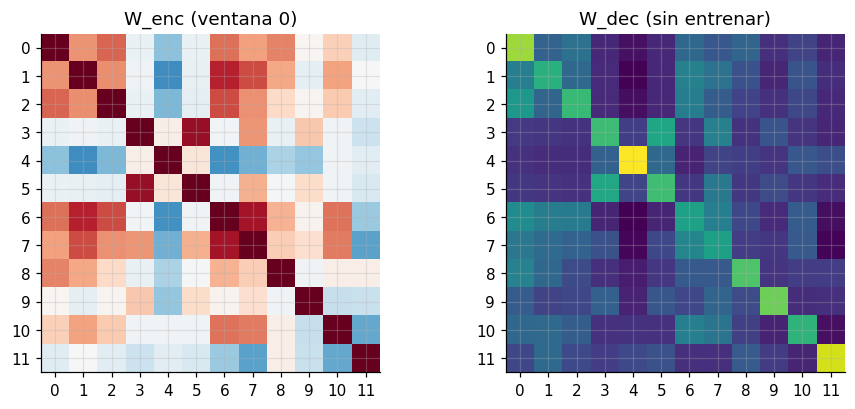

In [3]:
print(inspect.getsource(SimBlock))
sim = SimBlock(12).to(dev)
W = sim(xn)
print("W_dec:", tuple(W.shape), "| cada fila suma 1:", W.sum(-1)[0, :3].detach().cpu().numpy())
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow((xn.transpose(1, 2) @ xn / 336)[0].detach().cpu(), cmap="RdBu_r", vmin=-1, vmax=1); ax[0].set_title("W_enc (ventana 0)")
ax[1].imshow(W[0].detach().cpu(), cmap="viridis"); ax[1].set_title("W_dec (sin entrenar)")
for a in ax: a.set_xticks(range(12)); a.set_yticks(range(12))
plt.show()

## 3. Embedding "invertido": cada canal es un token

A diferencia de un Transformer clásico (un token por instante), aquí **cada variable completa de 336 h es un token**:
`Linear(336 → D)`. Así la atención modela relaciones **entre variables** (12 tokens), no entre horas.

In [4]:
D = 256
emb = torch.nn.Linear(336, D).to(dev)
tokens = emb(xn.transpose(1, 2))
print("x_norm:", tuple(xn.shape), "→ transponer →", tuple(xn.transpose(1, 2).shape), "→ Linear(336→256) →", tuple(tokens.shape))

x_norm: (8, 336, 12) → transponer → (8, 12, 336) → Linear(336→256) → (8, 12, 256)


## 4. ACE — Adaptive Channel Enhancer (Alg. 1, líneas 6–12)

Una matriz de bajo rango `W ∈ ℝ^{D×r}` (r = 32) pasa por un MLP + ReLU → `W_enh ∈ ℝ^{D×d}` (d = 64).
Cada token se proyecta: `x_low = x_emb · W_enh` (d "modos dominantes"), se concatena con el token original y se vuelve a
proyectar a D. Intuición: reforzar los patrones temporales dominantes (tendencias, recesiones) en cada canal.
La ablación (notebook 04) muestra que **es el componente con efecto más claro** (en el modelo final, sin ACE la NSE mediana cae ~0.05).

In [5]:
print(inspect.getsource(ACE))
ace = ACE(D, 32, 64).to(dev)
print("tokens:", tuple(tokens.shape), "→ ACE →", tuple(ace(tokens).shape), "| parámetros ACE:", sum(p.numel() for p in ace.parameters()))

class ACE(nn.Module):
    """Adaptive Channel Enhancer (Alg. 1, l. 6–12): realce de bajo rango compartido.

    W ∈ ℝ^{D×r} → W_enh = ReLU(Linear(r→d)(W)) ∈ ℝ^{D×d}; x_low = x_emb·W_enh; salida = Linear([x_emb, x_low]).
    Intuición: proyecta cada token a d "modos temporales dominantes" y los reinyecta en el token.
    """

    def __init__(self, D: int, r: int = 32, d: int = 64):
        super().__init__()
        self.W = nn.Parameter(torch.empty(D, r))
        nn.init.xavier_uniform_(self.W)
        self.mlp = nn.Linear(r, d)
        self.fuse = nn.Linear(D + d, D)

    def forward(self, x_emb):
        w_enh = F.relu(self.mlp(self.W)).to(x_emb.dtype)
        return self.fuse(torch.cat([x_emb, x_emb @ w_enh], dim=-1))

tokens: (8, 12, 256) → ACE → (8, 12, 256) | parámetros ACE: 92480


## 5. Encoder Transformer (y el token de cuenca, una extensión que probamos)

2 capas *pre-LayerNorm*, 8 cabezas, atención entre los 12 tokens de canal.

**Extensión probada: token de cuenca.** el dataset no trae atributos estáticos (área, suelo, pendiente), pero sí `basin_id` y
**las 508 cuencas de test están en train**. Añadimos un vector aprendido por cuenca (`nn.Embedding(508, D)`) como
**13.º token**. Los tokens de canal pueden atender a él y "saber" qué cuenca pronostican (cómo responde a la lluvia,
cuál es su flujo base…). Antes del ACF se descarta. En la ablación (notebook 04) **no mejoró**, así que el
modelo final no lo usa; aquí se muestra para explicar el mecanismo.

In [6]:
bmap = mapa_cuencas()
bidx = torch.tensor([bmap[int(b)] for b in va["basin"][:8].cpu()], device=dev)
basin_emb = torch.nn.Embedding(508, D).to(dev)
h = torch.cat([ace(tokens), basin_emb(bidx)[:, None, :]], 1)
print("12 tokens de canal + 1 token de cuenca:", tuple(h.shape))
layer = torch.nn.TransformerEncoderLayer(D, 8, 2 * D, 0.1, batch_first=True, norm_first=True, activation="gelu")
enc = torch.nn.TransformerEncoder(layer, 2, norm=torch.nn.LayerNorm(D), enable_nested_tensor=False).to(dev)
h = enc(h)[:, :12]
print("salida del encoder (sin el token de cuenca):", tuple(h.shape))

12 tokens de canal + 1 token de cuenca: (8, 13, 256)
salida del encoder (sin el token de cuenca): (8, 12, 256)


## 6. ACF — Adaptive Channel Forecaster (Ec. 2–3)

Para el objetivo i (aquí sólo el caudal, i = 11):

1. `C = [11, c₁, …, c_{k−1}]` → el caudal + los k−1 canales con mayor `W_dec[11, :]` (**distintos en cada muestra**).
2. `gather` toma esos k tokens → `[B, k, D]` → se aplanan → MLP → `[B, k, 48]`.
3. Se conserva sólo la **fila 0** (la del caudal).

**Adaptación:** el paper tiene un predictor por variable (pronostica las N). Aquí sólo hay un objetivo → un predictor.

In [7]:
NOMBRES = [c["name"] for c in json.loads((DATASET / "metadata.json").read_text())["channels"]]
print(inspect.getsource(ACF.seleccionar))
acf = ACF("topk", 4, 12, D, 512, 48, 0.1).to(dev)
y_norm, C = acf(h, W)
print("canales elegidos por muestra (k=4):")
for i in range(4):
    print(f"  ventana {i}:", [NOMBRES[c] for c in C[i].tolist()])
print("salida:", tuple(y_norm.shape))

    def seleccionar(self, w_dec):
        B = w_dec.shape[0]
        tgt = torch.full((B, 1), TARGET, dtype=torch.long, device=w_dec.device)
        if self.mode == "topk" and self.k > 1:
            s = w_dec[:, TARGET, :].clone()
            s[:, TARGET] = float("-inf")                # el caudal siempre va primero
            return torch.cat([tgt, s.topk(self.k - 1, dim=-1).indices], 1)
        if self.k == 1:
            return tgt
        return self.orden[None].expand(B, -1)

canales elegidos por muestra (k=4):
  ventana 0: ['specific_discharge', 'longwave_radiation', 'total_precipitation', 'shortwave_radiation']
  ventana 1: ['specific_discharge', 'wind_u', 'total_precipitation', 'longwave_radiation']
  ventana 2: ['specific_discharge', 'wind_u', 'specific_humidity', 'wind_v']
  ventana 3: ['specific_discharge', 'wind_u', 'longwave_radiation', 'total_precipitation']
salida: (8, 48)


## 7. ¿Cómo aprende el SimBlock si `topk` no es diferenciable? — demostración

`topk` devuelve **índices** (enteros): no hay gradiente hacia `W_dec` por la vía de la predicción. El `gather` sí deja
pasar gradiente hacia los tokens elegidos. Por eso el paper añade la **pérdida auxiliar (Ec. 6)**:

$$\mathcal{L} = \mathrm{MSE}(\hat y, y) + \lambda\,\frac{\lVert W_y - W_{dec}\rVert_F^2}{N},\qquad W_y = \mathrm{softmax}\Big(\tfrac{1}{L}Y_{fut}^\top Y_{fut}\Big)$$

donde `Y_fut` es el **futuro real** de las 12 variables (`y_aux` + `y`). Es decir: se le enseña al SimBlock a
*anticipar* qué canales estarán relacionados en el futuro. Lo comprobamos con autograd:

In [8]:
model = Adapformer(basin_emb=True).to(dev)
out = model(xb, bidx)
mse = ((out["y"] - 0.0) ** 2).mean()
mse.backward(retain_graph=True)
g_sim = sum(p.grad.abs().sum().item() for p in model.simblock.parameters() if p.grad is not None)
g_enc = sum(p.grad.abs().sum().item() for p in model.encoder.parameters() if p.grad is not None)
print(f"gradiente del MSE → SimBlock: {g_sim:.2e}   |   → encoder: {g_enc:.2e}")
model.zero_grad()
aux = ((out["W_dec"] - torch.eye(12, device=dev)) ** 2).sum((1, 2)).mean()
aux.backward()
g_sim = sum(p.grad.abs().sum().item() for p in model.simblock.parameters() if p.grad is not None)
print(f"gradiente de la pérdida auxiliar → SimBlock: {g_sim:.2e}  ✔ (sólo así aprende)")

gradiente del MSE → SimBlock: 0.00e+00   |   → encoder: 2.39e+01
gradiente de la pérdida auxiliar → SimBlock: 8.97e+00  ✔ (sólo así aprende)


## 8. El modelo completo y el modelo base

In [9]:
print(inspect.getsource(Adapformer.forward))
def n_par(m): return sum(p.numel() for p in m.parameters())
af = Adapformer(basin_emb=True)
partes = {"RevIN": af.revin, "SimBlock": af.simblock, "Embedding (336→D)": af.embed, "ACE": af.ace,
          "Token de cuenca": af.basin, "Encoder (2 capas)": af.encoder, "ACF (predictor)": af.acf}
display(pd.DataFrame({"parámetros": {k: n_par(v) for k, v in partes.items()}}).assign(**{"%": lambda d: (100 * d.parámetros / n_par(af)).round(1)}))
print(f"Adapformer total: {n_par(af):,}   |   LSTM base: {n_par(LSTMBase(basin_emb=True)):,}")

    def forward(self, x, basin_idx=None):
        with torch.autocast("cuda", enabled=False):
            x_norm = self.revin.norm(x.float())
            w_dec = self.simblock(x_norm)
        h = self.embed(x_norm.transpose(1, 2))                      # [B,N,D] cada canal = 1 token
        if self.embed_mlp is not None:
            h = h + self.embed_mlp(h)
        h = self.drop(h)
        if self.ace is not None:
            h = self.ace(h)
        if self.basin is not None:
            h = torch.cat([h, self.basin(basin_idx)[:, None, :].to(h.dtype)], 1)   # [B,N+1,D]
        h = self.encoder(h)[:, : self.N]                             # descartamos el token de cuenca
        y_norm, C = self.acf(h, w_dec)
        with torch.autocast("cuda", enabled=False):
            y = self.revin.denorm_target(y_norm.float(), self.anchor_last)
        return {"y": y, "W_dec": w_dec, "sel": C}



,parámetros,%
RevIN,24,0.0
SimBlock,1212,0.1
Embedding (336→D),86272,4.3
ACE,92480,4.7
Token de cuenca,130048,6.5
Encoder (2 capas),1054720,53.1
ACF (predictor),623296,31.4


Adapformer total: 1,988,052   |   LSTM base: 276,040


> El conteo de arriba corresponde a la variante de demostración (k = 4 y token de cuenca). El modelo final
> (k = 12, sin token) tiene **3.10 M** de parámetros y el LSTM base, **0.21 M**.

**Modelo base (LSTM):** 2 capas, hidden 128, recorre las 336 h de las 12 variables (misma RevIN y mismo anclaje) y una capa lineal produce las 48 h. Es el baseline "clásico" de
hidrología (Kratzert et al., 2018). Además usamos la **persistencia** como piso.

## Diferencias respecto al paper (resumen)

| Paper | Nuestra implementación | Por qué |
|---|---|---|
| Predice las N variables (un ACF por variable) | Un ACF sólo para el caudal | Única variable objetivo; la meteorología futura no existe en test |
| RevIN⁻¹ con la media | Anclaje al último caudal | Persistencia corr 0.98 a 1 h |
| `W_y = YYᵀ` sin normalizar | `softmax(YᵀY/L)` | Misma escala que `W_dec` (filas que suman 1) |
| ACE con `W ∈ ℝ^{N×D×r}` | `W ∈ ℝ^{D×r}` compartido | El texto habla de proyección compartida |
| Instance Normalization en el encoder | LayerNorm por token (pre-LN) | En el esquema invertido normaliza cada variable por separado |
| Entrada en z-score | `log1p` en caudal y lluvia + z-score; pérdida MSE en ese espacio | Colas pesadas; una pérdida híbrida con mm/h se probó y no mejoró |
| k ajustado por dataset (1–36) | k = 12: el ACF usa los 12 canales | Mejor MSE de validación en las 3 semillas (notebook 04) |
| Adam, batch 16–32, lr×0.5/época | AdamW, batch 512, γ=0.8 | 254 000 ventanas; con 0.5 el lr muere en 5 épocas |